## Multiple Linear 
### Task: Assignment Task: Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.



#### Task 1 : Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [28]:
# Step 1: Load the dataset
data = pd.read_csv('ToyotaCorolla - MLR.csv')
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [32]:
# Step 2: Perform Exploratory Data Analysis (EDA)
# Summary statistics
print("\nSummary Statistics:")
data.describe()


Summary Statistics:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


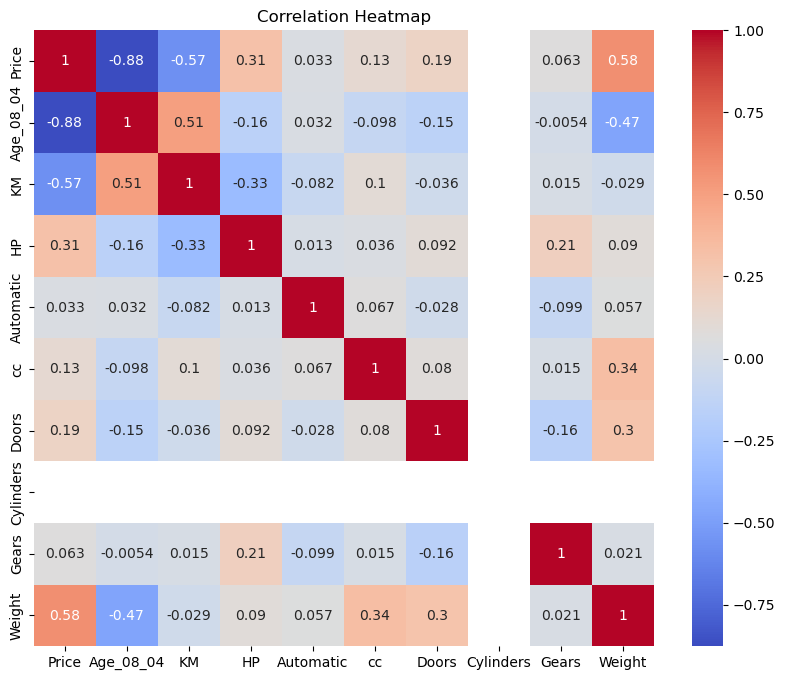

In [37]:
#correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [49]:
#numerical columns
numerical_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Doors',
                  'Cylinders', 'Gears', 'Weight']

['Price',
 'Age_08_04',
 'KM',
 'HP',
 'cc',
 'Doors',
 'Cylinders',
 'Gears',
 'Weight']

In [50]:
#categorical columns
categorical_cols = ['FuelType', 'Automatic']


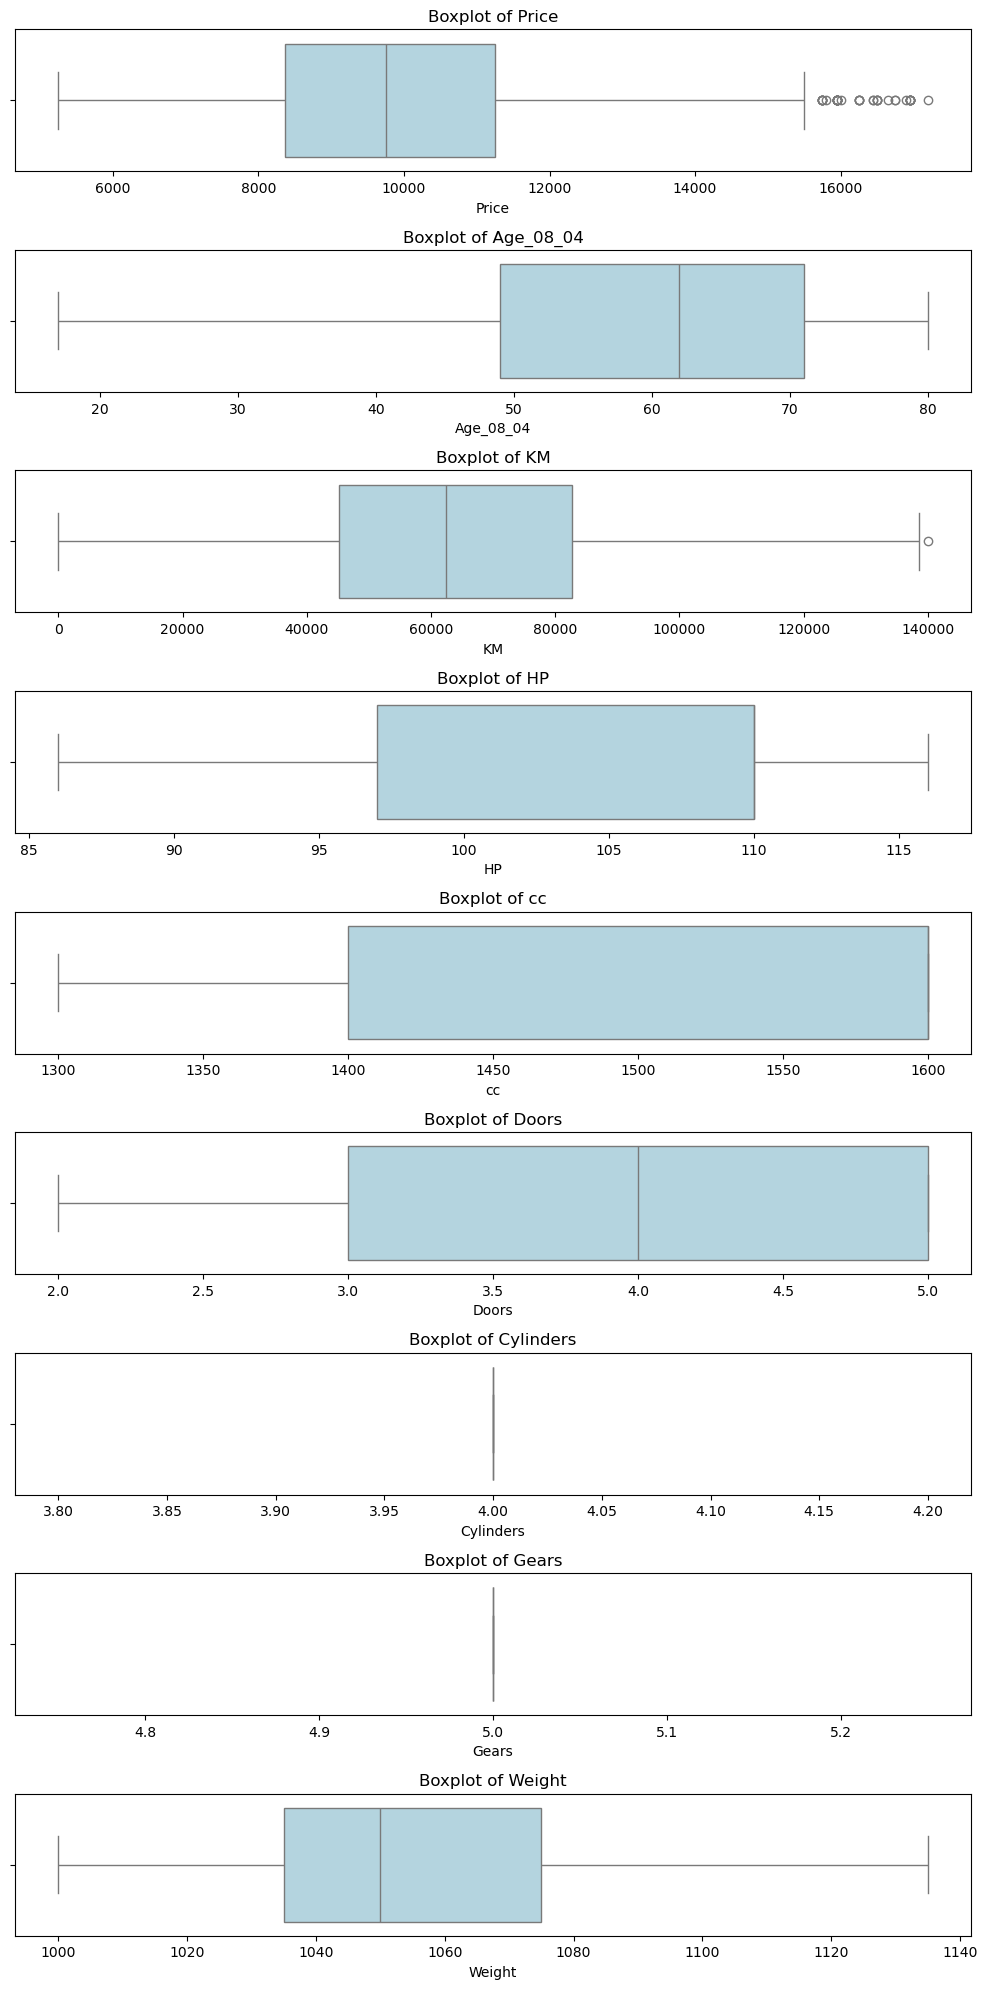

In [51]:
#boxplot for numerical columns to identify outliers
fig, axes= plt.subplots(len(numerical_cols), 1, figsize=(10, 20)) # create subplots for each numerical column where each subplot is 10x20 in size and the number of subplots is equal to the number of numerical columns
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=data, x=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [52]:
# Step 3: Handle Outliers using Interquartile Range (IQR)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [71]:
#remove outliers from numerical columns
columns_with_outliers = ['KM', 'HP', 'cc']
for col in columns_with_outliers:
    data = remove_outliers(data, col)

In [72]:
data.shape

(1059, 11)

In [ ]:
# Step 4: Encode categorical variables and normalize numerical features
# One-hot encode the 'Fuel_Type' column
data = pd.get_dummies(data, columns=['Fuel_Type'], drop_first=True)

In [58]:
data.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Petrol
18,16750,24,25563,110,0,1600,3,4,5,1065,1
19,16950,30,64359,110,0,1600,3,4,5,1105,1
20,15950,30,67660,110,0,1600,3,4,5,1105,1
22,15950,28,56349,110,0,1600,3,4,5,1120,1
23,16950,28,32220,110,0,1600,3,4,5,1120,1


In [59]:
#standardize numerical columns with StandardScaler
scaler = StandardScaler()
numerical_features = ['Age_08_04', 'KM', 'HP', 'cc', 'Weight']
data[numerical_features] = scaler.fit_transform(data[numerical_features])

In [60]:
data.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Petrol
18,16750,-2.309140,-1.484007,0.686241,0,0.707886,3,4,5,0.382995,1
19,16950,-1.914914,-0.021304,0.686241,0,0.707886,3,4,5,1.872770,1
20,15950,-1.914914,0.103152,0.686241,0,0.707886,3,4,5,1.872770,1
22,15950,-2.046323,-0.323300,0.686241,0,0.707886,3,4,5,2.431436,1
23,16950,-2.046323,-1.233022,0.686241,0,0.707886,3,4,5,2.431436,1


In [61]:
# Step 5: Split the dataset into training and testing sets
X = data.drop(columns=['Price']) # here drop the target variable 'Price' from the dataset as it is the target variable
y = data['Price'] # here assign the target variable 'Price' to y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # split the dataset into training and testing sets with 80% training and 20% testing

In [62]:
# Step 6: Build a Multiple Linear Regression (MLR) model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [70]:
from sklearn.metrics import root_mean_squared_error, r2_score
# Predict and evaluate the model
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [68]:
print("\nLinear Regression Model Performance:")
print(f"Training RMSE: {train_rmse}")
print(f"Testing RMSE: {test_rmse}")
print(f"Training R²: {train_r2}")
print(f"Testing R²: {test_r2}")


Linear Regression Model Performance:
Training RMSE: 965.3977674814358
Testing RMSE: 1017.7309306773501
Training R²: 0.8202080235722373
Testing R²: 0.8148345454800956


In [73]:
# Display coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
print("\nLinear Regression Coefficients:")
print(coefficients)
# these coefficients represent the change in the target variable 'Price' for a one unit change in the respective feature where negative coefficients indicate a decrease in 'Price' and positive coefficients indicate an increase in 'Price'


Linear Regression Coefficients:
            Feature   Coefficient
0         Age_08_04 -1.697195e+03
1                KM -3.235513e+02
2                HP -9.420649e+02
3         Automatic -7.882583e-13
4                cc  8.741495e+02
5             Doors -7.536399e+01
6         Cylinders  0.000000e+00
7             Gears  0.000000e+00
8            Weight  5.833794e+02
9  Fuel_Type_Petrol  3.304840e+02


In [75]:
# Step 7: Apply Ridge and Lasso Regression
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_test_pred_ridge = ridge_model.predict(X_test)
ridge_rmse = root_mean_squared_error(y_test, y_test_pred_ridge)
ridge_r2 = r2_score(y_test, y_test_pred_ridge)


In [76]:
# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_test_pred_lasso = lasso_model.predict(X_test)
lasso_rmse = root_mean_squared_error(y_test, y_test_pred_lasso)
lasso_r2 = r2_score(y_test, y_test_pred_lasso)


In [77]:
# Display Lasso coefficients
lasso_coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_model.coef_})

print("\nRidge Regression Performance:")
print(f"Testing RMSE: {ridge_rmse}")
print(f"Testing R²: {ridge_r2}")

print("\nLasso Regression Performance:")
print(f"Testing RMSE: {lasso_rmse}")
print(f"Testing R²: {lasso_r2}")

print("\nLasso Regression Coefficients:")
print(lasso_coefficients)


Ridge Regression Performance:
Testing RMSE: 1018.4972590728438
Testing R²: 0.8145555896889191

Lasso Regression Performance:
Testing RMSE: 1017.8506063724884
Testing R²: 0.8147909954479393

Lasso Regression Coefficients:
            Feature  Coefficient
0         Age_08_04 -1695.921667
1                KM  -323.538853
2                HP  -915.287989
3         Automatic     0.000000
4                cc   847.848841
5             Doors   -74.601031
6         Cylinders     0.000000
7             Gears     0.000000
8            Weight   582.208218
9  Fuel_Type_Petrol   318.368219


In [ ]:
#the coefficients of the Lasso regression model have been reduced to zero for some features, indicating that these features are not contributing to the prediction of the target variable 'Price' in the Lasso model whereas Ridge regression does not reduce the coefficients to zero.